In [13]:
import keras
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, BatchNormalization, ReLU, concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
@keras.saving.register_keras_serializable()
class JPEGALMLayer(Layer):
    def __init__(self, quant_table, T, filters_dct, filters_quant, **kwargs):
        super(JPEGALMLayer, self).__init__(**kwargs)
        self.quant_table = quant_table
        self.T = T
        self.filters_dct = filters_dct
        self.filters_quant = filters_quant

    def build(self, input_shape):
        self.dilated_conv_bn_relu = tf.keras.Sequential([
            Conv2D(filters=self.filters_dct, kernel_size=3, padding='same', dilation_rate=2),
            BatchNormalization(),
            ReLU()
        ])

        self.conv_bn_relu = tf.keras.Sequential([
            Conv2D(filters=self.filters_dct, kernel_size=3, padding='same'),  # Match filters_dct
            BatchNormalization(),
            ReLU()
        ])

        self.conv_low_freq = Conv2D(128, (1, 1), padding='same', activation='relu')
        self.conv_high_freq = Conv2D(128, (3, 3), padding='same', activation='relu')

    def call(self, inputs):
        # Perform DCT on inputs
        dct_coeffs = tf.signal.dct(inputs, type=2, norm='ortho')
        
        # Quantization based on quantization table
        repeated_table = tf.constant(self.quant_table, dtype=tf.float32)
        repeated_table = tf.expand_dims(repeated_table, axis=0)
        repeated_table = tf.tile(repeated_table, [tf.shape(dct_coeffs)[0], 1, 1])
        repeated_table = tf.expand_dims(repeated_table, axis=-1)

        x_dct = self.dilated_conv_bn_relu(dct_coeffs)
        x_quant = self.conv_bn_relu(repeated_table)

        # Ensure x_dct and x_quant have compatible shapes
        x_quant = tf.image.resize(x_quant, tf.shape(x_dct)[1:3])  # Resize x_quant to match x_dct's spatial dimensions

        x_combined = x_dct * x_quant
        x_combined_separated = self.frequency_separation(x_combined)
        
        return x_combined_separated

    def get_config(self):
        config = super(JPEGALMLayer, self).get_config()
        config.update({
            'quant_table': self.quant_table,
            'T': self.T,
            'filters_dct': self.filters_dct,
            'filters_quant': self.filters_quant
        })
        return config
    
    def frequency_separation(self, inputs):
        low_freq = self.conv_low_freq(inputs)
        high_freq = self.conv_high_freq(inputs)
        combined = concatenate([low_freq, high_freq], axis=-1)
        return combined
        
    @classmethod
    def from_config(cls, config):
        return cls(**config)
        
@keras.saving.register_keras_serializable()
class UpSample1x1Bilinear(Layer):
    def __init__(self, scale_factor=2, filters=None, **kwargs):
        super().__init__(**kwargs)
        self.scale_factor = scale_factor
        self.filters = filters
        self.conv = None

    def build(self, input_shape):
        # If filters are not provided, use the same number of input channels
        if self.filters is None:
            self.filters = input_shape[-1]
        # Define the 1x1 convolution layer
        self.conv = Conv2D(filters=self.filters, kernel_size=1, padding='same')

    def call(self, input_tensor):
        # Apply bilinear upsampling
        upsampled = tf.image.resize(input_tensor, 
                                    size=[tf.shape(input_tensor)[1] * self.scale_factor, 
                                          tf.shape(input_tensor)[2] * self.scale_factor], 
                                    method='bilinear')
        # Apply 1x1 convolution
        output = self.conv(upsampled)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "scale_factor": self.scale_factor,
            "filters": self.filters,
        })
        return config
        
@keras.saving.register_keras_serializable()
class AdjustSpatialDimensions(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AdjustSpatialDimensions, self).__init__(**kwargs)

    @tf.function
    def call(self, inputs):
        x, target_shape = inputs
        target_shape = tf.shape(target_shape)[1:3]
        resized = tf.image.resize(x, target_shape, method='bilinear')
        
        # Check for NaN values and raise an error if found
        tf.debugging.check_numerics(resized, "NaN values found in AdjustSpatialDimensions layer output")  
        return resized

    def get_config(self):
        config = super(AdjustSpatialDimensions, self).get_config()
        return config

@keras.saving.register_keras_serializable()
def weighted_binary_crossentropy(y_true, y_pred, weight=5.0):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weight_map = tf.where(tf.equal(y_true, 1), weight, 1)
    weighted_bce = weight_map * bce
    return tf.reduce_mean(weighted_bce)

def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch != 0:
        lr = lr * 0.1
    return lr

callback_lr = LearningRateScheduler(scheduler)

import tensorflow as tf
from tensorflow.keras.callbacks import Callback

@keras.saving.register_keras_serializable()
class SaveBestModel(Callback):
    def __init__(self, filepath, monitor_metrics):
        super(SaveBestModel, self).__init__()
        self.filepath = filepath
        self.monitor_metrics = monitor_metrics
        self.best_metrics = {key: None for key in monitor_metrics}

    def get_config(self):
        config = super(SaveBestModel, self).get_config()
        config.update({
            'filepath': self.filepath,
            'monitor_metrics': self.monitor_metrics
        })
        return config
        
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        save = False
        for key, mode in self.monitor_metrics.items():
            current = logs.get(key)
            if current is not None:
                if self.best_metrics[key] is None or \
                        (mode == 'min' and current < self.best_metrics[key]) or \
                        (mode == 'max' and current > self.best_metrics[key]):
                    self.best_metrics[key] = current
                    save = True
        if save:
            save_path = self.filepath.format(epoch=epoch, **logs)
            tf.saved_model.save(self.model, save_path)
            print(f"Saved model at epoch {epoch} based on improved metrics: {self.best_metrics}")



In [16]:
import tensorflow as tf

# Define the custom objects dictionary
custom_objects = {
    'JPEGALMLayer': JPEGALMLayer,
    'UpSample1x1Bilinear': UpSample1x1Bilinear,
    'AdjustSpatialDimensions': AdjustSpatialDimensions,
    'weighted_binary_crossentropy': weighted_binary_crossentropy,
    'SaveBestModel': SaveBestModel
}

# Load the model with the custom object scope
with tf.keras.utils.custom_object_scope(custom_objects):
    loaded_model = tf.keras.models.load_model("main.keras")

# Print the model summary
loaded_model.summary()


ValueError: File not found: filepath=128x128casia2_simplecatnet.keras. Please ensure the file is an accessible `.keras` zip file.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction shape: (1, 128, 128, 1)


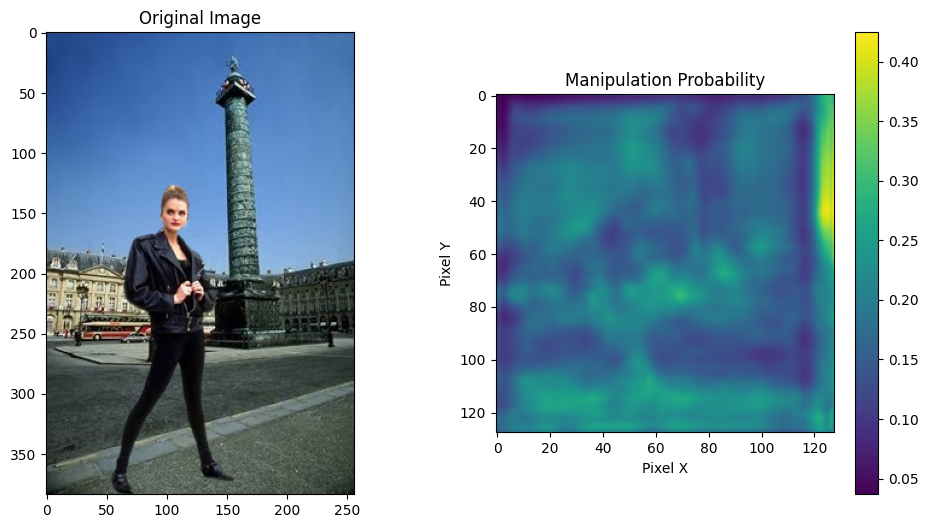

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import jpegio as jio
import cv2

# Path to the image to be predicted
image_path = r'D:\dataset\archive\CASIA2\Tp\Tp_D_NRN_M_B_arc00030_cha00028_20106.jpg'

# Preprocess the image
def preprocess_image(filepath, img_height, img_width):
    img = load_img(filepath, target_size=(img_height, img_width))
    img = img_to_array(img) / 255.0
    return img

# Preprocess the DCT coefficients
def preprocess_dct(filepath, img_height, img_width):
    jpeg_struct = jio.read(filepath)
    dct_coeff = jpeg_struct.coef_arrays[0]  # Assuming Y channel
    dct_coeff = dct_coeff.astype(np.float32)
    dct_coeff = dct_coeff / np.max(np.abs(dct_coeff) + 1e-8)  # Avoid division by zero
    dct_coeff = cv2.resize(dct_coeff, (img_width, img_height))
    dct_coeff = dct_coeff[:, :, np.newaxis]  # Add channel dimension
    return dct_coeff

# Preprocess the image and DCT coefficients
img_height = 128
img_width = 128
preprocessed_image = preprocess_image(image_path, img_height, img_width)
preprocessed_dct = preprocess_dct(image_path, img_height, img_width)

# Expand dimensions to match the batch size expected by the model
preprocessed_image = np.expand_dims(preprocessed_image, axis=0)
preprocessed_dct = np.expand_dims(preprocessed_dct, axis=0)

# Make predictions
prediction = loaded_model.predict([preprocessed_image, preprocessed_dct])

# Print the shape of the prediction output
print("Prediction shape:", prediction.shape)

# Extract the first sample's prediction map
manipulation_probability = prediction[0]

def display_image_with_prediction(image_path, probability):
    # Load the original image
    original_image = load_img(image_path)
    original_image = img_to_array(original_image) / 255.0  # Rescale

    # Display the images and probability map
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_image)

    plt.subplot(1, 2, 2)
    plt.title("Manipulation Probability")
    plt.imshow(probability, cmap='viridis')
    plt.colorbar()
    plt.xlabel('Pixel X')
    plt.ylabel('Pixel Y')

    plt.show()

# Display the original image and the manipulation probability map
display_image_with_prediction(image_path, manipulation_probability)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, BatchNormalization, ReLU, concatenate
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, LearningRateScheduler
custom_objects = {
    'JPEGALMLayer': JPEGALMLayer,
    'UpSample1x1Bilinear': UpSample1x1Bilinear,
    'AdjustSpatialDimensions': AdjustSpatialDimensions,
    'weighted_binary_crossentropy': weighted_binary_crossentropy,
    'SaveBestModel': SaveBestModel
}

# Load the model
loaded_model = tf.keras.models.load_model("main.h5", custom_objects=custom_objects)

# Print the model summary
loaded_model.summary()